In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks',
              rc={'axes.facecolor': (0, 0, 0, 0)})
sns.set_context('paper')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['figure.dpi'] = 150

In [2]:
from scipy import integrate

In [3]:
import numpy as np
import pandas as pd
from scipy.integrate import trapezoid

In [4]:
strains_order = ['PL', 'PM', 'LM',
                 'PL+PM', 'LM+PL', 'LM+PM',
                 'TriComm']
media_order = ['M9',
               'M9+Lys', 'M9+Met', 'M9+Phe',
               'M9+Lys+Met', 'M9+Lys+Phe', 'M9+Met+Phe',
               'M9+Lys+Met+Phe']
ds = {'PL': 'Single',
      'PM': 'Single',
      'LM': 'Single',
      'PL+PM': 'Double',
      'LM+PL': 'Double',
      'LM+PM': 'Double',
      'TriComm': 'TriComm'}
dm = {'M9': 'M9',
      'M9+Lys': 'M9+1AA',
      'M9+Met': 'M9+1AA',
      'M9+Phe': 'M9+1AA',
      'M9+Lys+Met': 'M9+2AA',
      'M9+Lys+Phe': 'M9+2AA',
      'M9+Met+Phe': 'M9+2AA',
      'M9+Lys+Met+Phe': 'M9+Lys+Met+Phe'}

In [5]:
m = pd.read_csv('../data/batch/rep_1.tsv', sep='\t')
m = m[m['time'] <= 61].copy()

In [6]:
m['scateg'] = [ds[x] for x in m['strain'].values]
m['mcateg'] = [dm[x] for x in m['treatment'].values]

In [7]:
a = m.groupby(['strain', 'treatment', 'row', 'column']
         ).apply(lambda x:
                 trapezoid(x['od600'], x['time']),
                 include_groups=False
                ).reset_index().rename(columns={0: 'auc'})

In [8]:
a['scateg'] = [ds[x] for x in a['strain'].values]
a['mcateg'] = [dm[x] for x in a['treatment'].values]

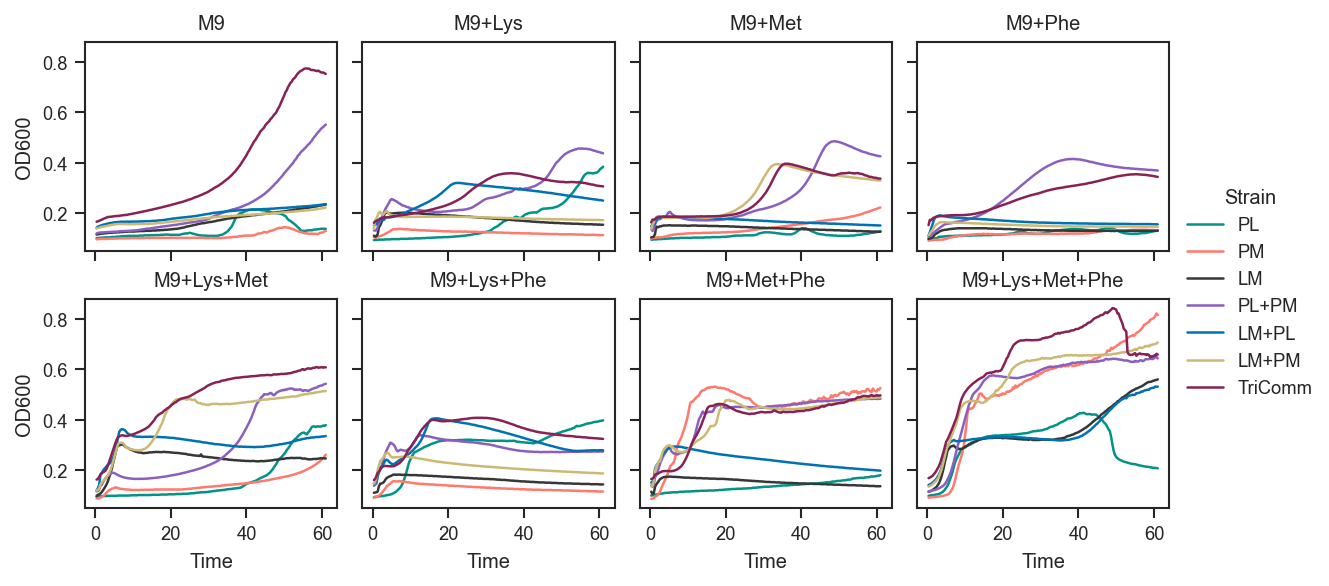

In [9]:
rp = sns.relplot(data=m,
                 x='time',
                 y='od600',
                 col='treatment',
                 hue='strain',
                 kind='line',
                 errorbar=None,
                 col_wrap=4,
                 height=2,
                 palette=[
                          'xkcd:teal',
                          'xkcd:salmon',
                          'xkcd:dark grey',

                          '#8B5FBF',
                          '#0072B2',
                          '#CCB974',

                          '#882255'
                          ],
                hue_order=strains_order,
                col_order=media_order)

# change legend title
rp._legend.set_title('Strain')

rp.set(xlabel='Time', ylabel='OD600')
rp.set_titles('{col_name}')

plt.subplots_adjust(wspace=0.1, hspace=0.225)

sns.despine(top=False, right=False);

/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 8.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


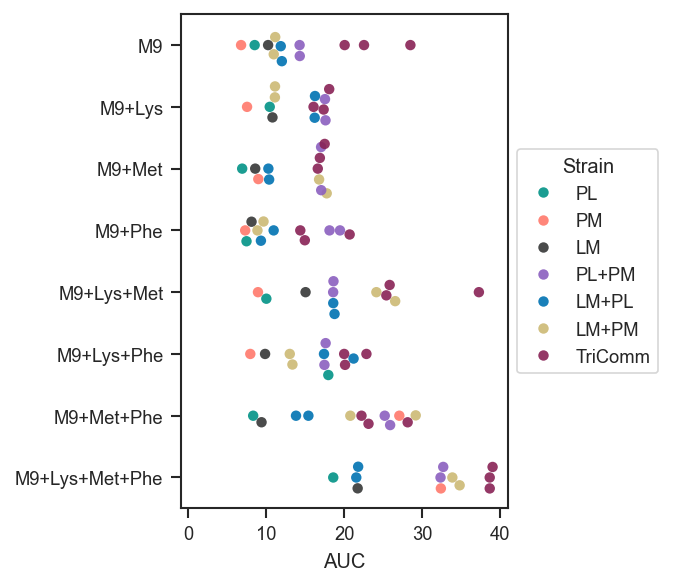

In [10]:
rp = sns.catplot(data=a,
                 y='treatment',
                 x='auc',
                 hue='strain',
                 kind='swarm',
                 # errorbar=None,
                 # jitter=0.2,
                 height=4, aspect=1,
                 palette=[
                          'xkcd:teal',
                          'xkcd:salmon',
                          'xkcd:dark grey',

                          '#8B5FBF',
                          '#0072B2',
                          '#CCB974',

                          '#882255'
                          ],
                 hue_order=strains_order,
                 order=media_order,
                 alpha=.9)

# remove the legend
rp._legend.remove()

plt.legend(facecolor='w',
           title='Strain',
           bbox_to_anchor=(1, 0.5),
           loc='center left')

rp.set(xlabel='AUC', ylabel='',
       xlim=(-1, 41))

sns.despine(top=False, right=False);

In [11]:
b = a.pivot_table(index='strain', columns='treatment', values='auc',
                  aggfunc='mean'
                 ).reindex(strains_order).reindex(media_order, axis=1)

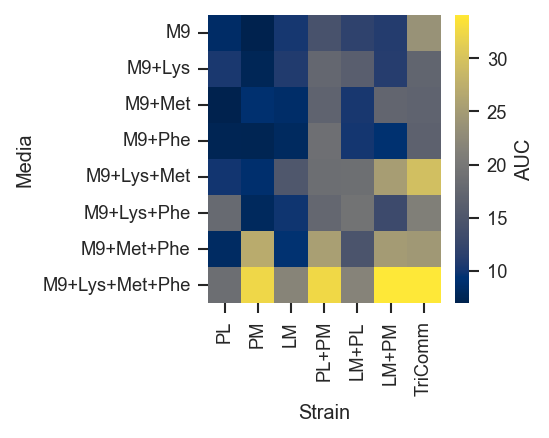

In [17]:
plt.figure(figsize=(2.5, 2.5))

hm = sns.heatmap(data=b.T,
                 cmap='cividis',
                 robust=True)

hm.figure.axes[-1
    ].set_ylabel('AUC')

plt.xlabel('Strain')
plt.ylabel('Media');

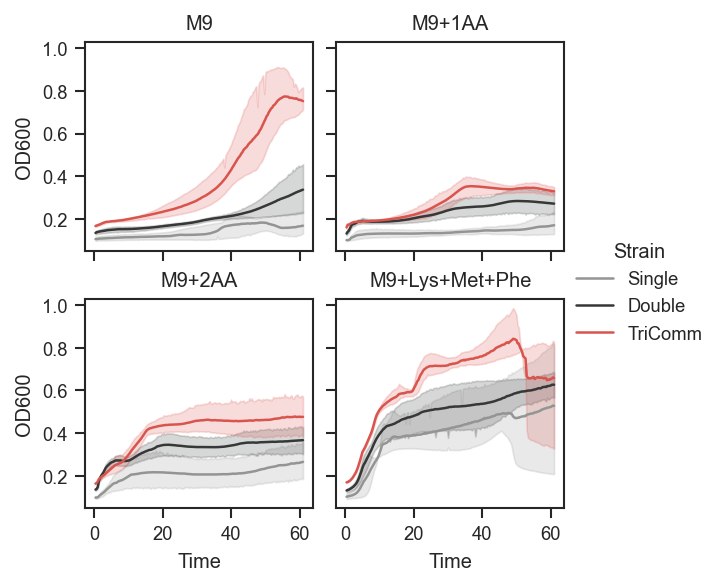

In [19]:
rp = sns.relplot(data=m,
                 x='time',
                 y='od600',
                 col='mcateg',
                 hue='scateg',
                 kind='line',
                 # errorbar='sd',
                 col_wrap=2,
                 height=2,
                 palette=[
                          'xkcd:grey',
                          'xkcd:dark grey',
                          'xkcd:pale red',
                          ],
                # hue_order=strains_order,
                # col_order=media_order
                )

# change legend title
rp._legend.set_title('Strain')

rp.set(xlabel='Time', ylabel='OD600')
rp.set_titles('{col_name}')

plt.subplots_adjust(wspace=0.1, hspace=0.225)

sns.despine(top=False, right=False);

In [14]:
c = a.pivot_table(index='scateg', columns='mcateg', values='auc',
                  aggfunc='mean'
                 ).reindex(['Single', 'Double', 'TriComm'])

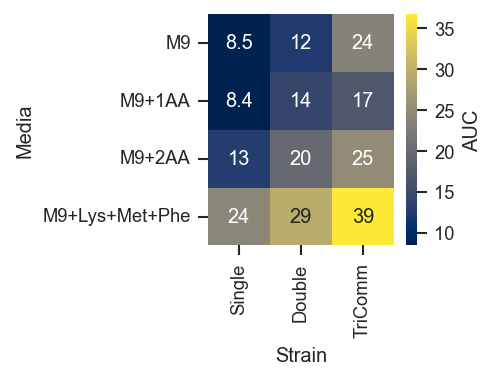

In [18]:
plt.figure(figsize=(2, 2))

hm = sns.heatmap(data=c.T,
            cmap='cividis',
            annot=True,
            robust=True)

hm.figure.axes[-1
    ].set_ylabel('AUC')

plt.xlabel('Strain')
plt.ylabel('Media');